# ETH/USD — Zonas de alta probabilidad estadística (Order Blocks / Estructura de mercado)

Implementa las reglas descritas para operar zonas de **Order Block** con una **tasa de continuación estadística**, usando **tres temporalidades**: **1 hora**, **15 minutos** y **5 minutos**.

**Las tres temporalidades detectan su propio Order Block y generan su propia entrada, Stop Loss y Take Profit** de forma independiente (tres señales operables):

- **1h**: es la temporalidad más alta del sistema, no tiene una temporalidad superior que la confirme (se considera alineada por definición).
- **15m**: su zona se valida contra la tendencia de **1h**.
- **5m**: su zona se valida contra la tendencia de **1h y 15m**.

1. **Análisis de probabilidad** *(03:13–04:32)*: para cada zona (1h, 15m, 5m) se analizan sus últimas **90 zonas similares** y sus últimos **30 quiebres de estructura** (en su propia temporalidad) para calcular una *tasa de continuación*. Se recomienda operar zonas con probabilidad **> 50%**.
2. **Multi-temporalidad** *(15:28–15:37)*: el video pide "al menos dos temporalidades"; aquí cada zona operable (15m, 5m) se confirma contra la(s) temporalidad(es) superior(es); 1h no requiere confirmación al ser la más alta.
3. **Confirmación de entrada** *(29:58–30:29)*: se evita operar si la probabilidad está en 50% o neutral, o si la(s) temporalidad(es) superior(es) no coinciden en dirección.
4. **Sesiones horarias** *(11:27–12:08)*: por defecto `02:00–05:00` y `07:00–12:00` en huso horario `America/New_York` (killzones de Londres y Nueva York), aplicado a las tres señales.
5. **Gestión del trade**: Stop Loss justo fuera del Order Block *(05:53)*, Take Profit en la siguiente zona de liquidez *(05:57)* y una **regla de tiempo de 45 minutos** *(32:24–32:38)*, para cada señal.

Los gráficos usan **matplotlib** (interfaz orientada a objetos `fig, ax = plt.subplots()`). Las tres temporalidades se grafican con su propia zona Order Block y niveles del trade.

### Fuente de datos

**Alpaca** como fuente principal (`.env`), con **respaldo automático** a la API pública de Binance si Alpaca no responde.

### ⚠️ Aviso importante

La "tasa de continuación" es un **backtest simplificado sobre datos recientes**, no una probabilidad de mercado garantizada. Herramienta educativa, no asesoría financiera.

## 1. Configuración

In [11]:
import os
import datetime as dt
import numpy as np
import pandas as pd
import requests
import ta
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown
from dotenv import load_dotenv

load_dotenv()

ALPACA_API_KEY_ID = os.getenv("ALPACA_API_KEY_ID", "")
ALPACA_API_SECRET_KEY = os.getenv("ALPACA_API_SECRET_KEY", "")

# --- Símbolo ---
SYMBOL_ALPACA = "ETH/USD"
SYMBOL_BINANCE = "ETHUSDT"

# --- Temporalidades: 1h, 15m y 5m, cada una con su propia zona ---
TF_MACRO_ALPACA, TF_MACRO_BINANCE = "1Hour", "1h"
TF_DIRECCION_ALPACA, TF_DIRECCION_BINANCE = "15Min", "15m"
TF_ENTRADA_ALPACA, TF_ENTRADA_BINANCE = "5Min", "5m"

DIAS_MACRO = 90    # historial a descargar en 1h
DIAS_HTF = 45      # historial a descargar en 15m
DIAS_LTF = 12      # historial a descargar en 5m

# --- Estructura de mercado / Order Blocks ---
SWING_LOOKBACK = 3          # velas a cada lado para confirmar un swing high/low (fractal)
VENTANA_RESULTADO = 60      # velas máximas para juzgar si una zona "continuó" o "falló" tras ser testeada

# --- Regla de probabilidad ---
N_ZONAS_SIMILARES = 90      # "últimas 90 zonas similares a la actual"
N_QUIEBRES_ESTRUCTURA = 30  # "últimos 30 quiebres de estructura"
PESO_ZONAS = 0.6            # ponderación de la tasa por zonas similares en la probabilidad final
PESO_QUIEBRES = 0.4         # ponderación de la tasa por quiebres recientes
UMBRAL_PROBABILIDAD = 50.0  # % mínimo recomendado para considerar la zona
BANDA_NEUTRAL = (45, 55)    # % — dentro de esta banda se considera "neutral" y no se opera

# --- Sesiones horarias (killzones ICT: Londres 02-05, NY 07-12, hora America/New_York) ---
SESIONES = [("02:00", "05:00"), ("07:00", "12:00")]
ZONA_HORARIA = "America/New_York"

# --- Gestión del trade ---
SL_BUFFER_ATR = 0.15        # colchón adicional del Stop Loss más allá del borde del Order Block, en múltiplos de ATR14
REGLA_TIEMPO_MIN = 45       # minutos máximos antes de preferir cerrar una operación sin desarrollo

## 2. Obtención de datos multi-temporalidad (Alpaca → respaldo Binance)

Se descarga el historial completo (`DIAS_MACRO` / `DIAS_HTF` / `DIAS_LTF`) con paginación para las tres temporalidades.

In [12]:
def obtener_velas_alpaca_historico(symbol, timeframe, dias):
    if not ALPACA_API_KEY_ID or not ALPACA_API_SECRET_KEY:
        raise ValueError("ALPACA_API_KEY_ID / ALPACA_API_SECRET_KEY no configuradas en .env")
    headers = {"APCA-API-KEY-ID": ALPACA_API_KEY_ID, "APCA-API-SECRET-KEY": ALPACA_API_SECRET_KEY}
    end = dt.datetime.now(dt.timezone.utc)
    start = end - dt.timedelta(days=dias)
    all_bars, page_token = [], None
    while True:
        params = {"symbols": symbol, "timeframe": timeframe, "start": start.isoformat(),
                   "end": end.isoformat(), "limit": 10000, "sort": "asc"}
        if page_token:
            params["page_token"] = page_token
        r = requests.get("https://data.alpaca.markets/v1beta3/crypto/us/bars",
                          headers=headers, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()
        all_bars.extend(data["bars"].get(symbol, []))
        page_token = data.get("next_page_token")
        if not page_token:
            break
    df = pd.DataFrame(all_bars).rename(columns={"t": "timestamp", "o": "open", "h": "high",
                                                  "l": "low", "c": "close", "v": "volume"})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.set_index("timestamp")[["open", "high", "low", "close", "volume"]]


def obtener_velas_binance_historico(symbol, interval, dias):
    end_ms = int(dt.datetime.now(dt.timezone.utc).timestamp() * 1000)
    start_ms = end_ms - dias * 24 * 3600 * 1000
    all_rows, cur = [], start_ms
    while cur < end_ms:
        params = {"symbol": symbol, "interval": interval, "limit": 1000, "startTime": cur, "endTime": end_ms}
        r = requests.get("https://api.binance.com/api/v3/klines", params=params, timeout=20)
        r.raise_for_status()
        batch = r.json()
        if not batch:
            break
        all_rows.extend(batch)
        last_open = batch[-1][0]
        if last_open <= cur:
            break
        cur = last_open + 1
        if len(batch) < 1000:
            break
    cols = ["open_time", "open", "high", "low", "close", "volume", "close_time",
            "qav", "trades", "tbbav", "tbqav", "ignore"]
    df = pd.DataFrame(all_rows, columns=cols)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    df = df.set_index("timestamp")[["open", "high", "low", "close", "volume"]]
    return df[~df.index.duplicated(keep="first")].sort_index()


def obtener_velas_historico(symbol_alpaca, symbol_binance, tf_alpaca, tf_binance, dias):
    try:
        df = obtener_velas_alpaca_historico(symbol_alpaca, tf_alpaca, dias)
        if df.empty:
            raise ValueError("Alpaca devolvió 0 velas")
        return df, "Alpaca"
    except Exception as e:
        print(f"⚠️  Alpaca no disponible ({e}). Usando respaldo gratuito: Binance public API...")
        df = obtener_velas_binance_historico(symbol_binance, tf_binance, dias)
        return df, "Binance (respaldo)"


df_macro, fuente_macro = obtener_velas_historico(SYMBOL_ALPACA, SYMBOL_BINANCE,
                                                  TF_MACRO_ALPACA, TF_MACRO_BINANCE, DIAS_MACRO)
df_htf, fuente_htf = obtener_velas_historico(SYMBOL_ALPACA, SYMBOL_BINANCE,
                                              TF_DIRECCION_ALPACA, TF_DIRECCION_BINANCE, DIAS_HTF)
df_ltf, fuente_ltf = obtener_velas_historico(SYMBOL_ALPACA, SYMBOL_BINANCE,
                                              TF_ENTRADA_ALPACA, TF_ENTRADA_BINANCE, DIAS_LTF)

print(f"✅ 1h: {len(df_macro)} velas de {fuente_macro}, desde {df_macro.index[0]} hasta {df_macro.index[-1]}")
print(f"✅ 15m: {len(df_htf)} velas de {fuente_htf}, desde {df_htf.index[0]} hasta {df_htf.index[-1]}")
print(f"✅ 5m: {len(df_ltf)} velas de {fuente_ltf}, desde {df_ltf.index[0]} hasta {df_ltf.index[-1]}")

⚠️  Alpaca no disponible (401 Client Error: Unauthorized for url: https://data.alpaca.markets/v1beta3/crypto/us/bars?symbols=ETH%2FUSD&timeframe=1Hour&start=2026-04-28T03%3A27%3A08.368247%2B00%3A00&end=2026-07-27T03%3A27%3A08.368247%2B00%3A00&limit=10000&sort=asc). Usando respaldo gratuito: Binance public API...
⚠️  Alpaca no disponible (401 Client Error: Unauthorized for url: https://data.alpaca.markets/v1beta3/crypto/us/bars?symbols=ETH%2FUSD&timeframe=15Min&start=2026-06-12T03%3A27%3A15.325060%2B00%3A00&end=2026-07-27T03%3A27%3A15.325060%2B00%3A00&limit=10000&sort=asc). Usando respaldo gratuito: Binance public API...
⚠️  Alpaca no disponible (401 Client Error: Unauthorized for url: https://data.alpaca.markets/v1beta3/crypto/us/bars?symbols=ETH%2FUSD&timeframe=5Min&start=2026-07-15T03%3A27%3A20.138652%2B00%3A00&end=2026-07-27T03%3A27%3A20.138652%2B00%3A00&limit=10000&sort=asc). Usando respaldo gratuito: Binance public API...
✅ 1h: 2160 velas de Binance (respaldo), desde 2026-04-28 04

## 3. Detección de swings y estructura de mercado

Un **swing high/low** es un máximo/mínimo local confirmado por `SWING_LOOKBACK` velas a cada lado. Un **quiebre de estructura** ocurre cuando el cierre supera el último swing high confirmado (quiebre alcista) o perfora el último swing low confirmado (quiebre bajista). El **Order Block** de ese quiebre es la última vela de color opuesto al movimiento impulsivo que lo originó. Se detecta en las tres temporalidades.

In [13]:
def detectar_swings(df, lookback=SWING_LOOKBACK):
    df = df.copy()
    ventana = 2 * lookback + 1
    roll_max = df["high"].rolling(ventana, center=True).max()
    roll_min = df["low"].rolling(ventana, center=True).min()
    df["swing_high"] = df["high"] == roll_max
    df["swing_low"] = df["low"] == roll_min
    return df


def detectar_estructura(df):
    """Recorre las velas cronológicamente y detecta quiebres de estructura (BOS) junto
    con el Order Block (última vela opuesta antes del impulso) que originó cada quiebre."""
    ultimo_sh = ultimo_sl = None
    quiebres = []
    tendencia = None

    idx_list = df.index
    highs, lows = df["high"].values, df["low"].values
    opens, closes = df["open"].values, df["close"].values
    sh_flags, sl_flags = df["swing_high"].values, df["swing_low"].values

    for i in range(len(df)):
        if sh_flags[i]:
            ultimo_sh = (i, highs[i])
        if sl_flags[i]:
            ultimo_sl = (i, lows[i])

        if ultimo_sh is not None and closes[i] > ultimo_sh[1] and i > ultimo_sh[0]:
            i_origen = ultimo_sl[0] if ultimo_sl is not None else max(0, ultimo_sh[0] - 1)
            idx_ob = next((j for j in range(i, i_origen - 1, -1) if closes[j] < opens[j]), None)
            if idx_ob is not None:
                quiebres.append({"idx_break": i, "tiempo_break": idx_list[i], "tipo": "alcista",
                                  "nivel_roto": ultimo_sh[1], "idx_ob": idx_ob, "tiempo_ob": idx_list[idx_ob],
                                  "zona_low": lows[idx_ob], "zona_high": highs[idx_ob]})
            ultimo_sh = None
            tendencia = "alcista"

        elif ultimo_sl is not None and closes[i] < ultimo_sl[1] and i > ultimo_sl[0]:
            i_origen = ultimo_sh[0] if ultimo_sh is not None else max(0, ultimo_sl[0] - 1)
            idx_ob = next((j for j in range(i, i_origen - 1, -1) if closes[j] > opens[j]), None)
            if idx_ob is not None:
                quiebres.append({"idx_break": i, "tiempo_break": idx_list[i], "tipo": "bajista",
                                  "nivel_roto": ultimo_sl[1], "idx_ob": idx_ob, "tiempo_ob": idx_list[idx_ob],
                                  "zona_low": lows[idx_ob], "zona_high": highs[idx_ob]})
            ultimo_sl = None
            tendencia = "bajista"

    return pd.DataFrame(quiebres), tendencia


df_macro = detectar_swings(df_macro)
df_htf = detectar_swings(df_htf)
df_ltf = detectar_swings(df_ltf)

quiebres_macro, tendencia_macro = detectar_estructura(df_macro)
quiebres_htf, tendencia_htf = detectar_estructura(df_htf)
quiebres_ltf, tendencia_ltf = detectar_estructura(df_ltf)

print(f"1h: {len(quiebres_macro)} quiebres. Tendencia actual: {tendencia_macro}")
print(f"15m: {len(quiebres_htf)} quiebres. Tendencia actual: {tendencia_htf}")
print(f"5m: {len(quiebres_ltf)} quiebres. Tendencia actual: {tendencia_ltf}")

1h: 83 quiebres. Tendencia actual: alcista
15m: 165 quiebres. Tendencia actual: alcista
5m: 145 quiebres. Tendencia actual: alcista


## 4. Evaluación histórica de resultados (¿continuó o falló cada zona?)

Para cada Order Block detectado, en **1h**, **15m** y **5m**:

1. Se busca el primer momento en que el precio **regresa a testear** la zona `[zona_low, zona_high]` tras el quiebre.
2. Desde ese "toque", en una ventana de `VENTANA_RESULTADO` velas, se clasifica como:
   - **`continuo`**: el cierre alcanza el objetivo (`nivel_roto ± altura_de_la_zona` a favor de la dirección del quiebre) antes de invalidar.
   - **`fallo`**: el cierre atraviesa el lado contrario de la zona (invalidación) antes de alcanzar el objetivo.
   - **`sin_toque`** / **`sin_definir`**: el precio no volvió a testear la zona, o no se definió un resultado claro en la ventana.

In [14]:
def evaluar_resultado_obs(df, obs, ventana_resultado=VENTANA_RESULTADO):
    highs, lows, closes = df["high"].values, df["low"].values, df["close"].values
    n = len(df)
    resultados = []

    for row in obs.itertuples():
        zona_low, zona_high = row.zona_low, row.zona_high
        altura = zona_high - zona_low
        if altura <= 0:
            resultados.append("sin_definir")
            continue

        if row.tipo == "alcista":
            objetivo, invalidacion = row.nivel_roto + altura, zona_low
        else:
            objetivo, invalidacion = row.nivel_roto - altura, zona_high

        idx_tap = None
        for j in range(row.idx_break + 1, min(n, row.idx_break + 1 + ventana_resultado * 3)):
            if lows[j] <= zona_high and highs[j] >= zona_low:
                idx_tap = j
                break
        if idx_tap is None:
            resultados.append("sin_toque")
            continue

        resultado = "sin_definir"
        for j in range(idx_tap, min(n, idx_tap + ventana_resultado)):
            if row.tipo == "alcista":
                if closes[j] <= invalidacion:
                    resultado = "fallo"; break
                if closes[j] >= objetivo:
                    resultado = "continuo"; break
            else:
                if closes[j] >= invalidacion:
                    resultado = "fallo"; break
                if closes[j] <= objetivo:
                    resultado = "continuo"; break
        resultados.append(resultado)

    obs = obs.copy()
    obs["resultado"] = resultados
    return obs


def tasa_continuacion(obs_resultado, n_ultimas, tipo=None):
    sub = obs_resultado if tipo is None else obs_resultado[obs_resultado["tipo"] == tipo]
    sub = sub[sub["resultado"].isin(["continuo", "fallo"])].tail(n_ultimas)
    if len(sub) == 0:
        return None, 0
    return round(100 * (sub["resultado"] == "continuo").mean(), 1), len(sub)


obs_resultado_macro = evaluar_resultado_obs(df_macro, quiebres_macro)
obs_resultado_htf = evaluar_resultado_obs(df_htf, quiebres_htf)
obs_resultado_ltf = evaluar_resultado_obs(df_ltf, quiebres_ltf)

print("Resultados históricos — 1h:")
print(obs_resultado_macro["resultado"].value_counts())
print("\nResultados históricos — 15m:")
print(obs_resultado_htf["resultado"].value_counts())
print("\nResultados históricos — 5m:")
print(obs_resultado_ltf["resultado"].value_counts())

Resultados históricos — 1h:
resultado
fallo          36
continuo       32
sin_toque      14
sin_definir     1
Name: count, dtype: int64

Resultados históricos — 15m:
resultado
fallo          82
continuo       58
sin_toque      24
sin_definir     1
Name: count, dtype: int64

Resultados históricos — 5m:
resultado
fallo          78
continuo       49
sin_toque      17
sin_definir     1
Name: count, dtype: int64


## 5. Filtro de sesión horaria (Regla 4)

Se calcula una sola vez y se aplica a las tres señales, ya que dependen del mismo momento real.

In [15]:
def verificar_sesion(timestamp, sesiones=SESIONES, zona=ZONA_HORARIA):
    ts = timestamp.tz_localize("UTC") if timestamp.tzinfo is None else timestamp
    ts_local = ts.tz_convert(zona)
    hora = ts_local.time()
    for ini, fin in sesiones:
        h_ini = dt.datetime.strptime(ini, "%H:%M").time()
        h_fin = dt.datetime.strptime(fin, "%H:%M").time()
        if h_ini <= hora <= h_fin:
            return True, ts_local
    return False, ts_local


en_sesion, hora_local = verificar_sesion(df_ltf.index[-1])
print(f"Hora actual ({ZONA_HORARIA}): {hora_local.strftime('%Y-%m-%d %H:%M:%S %Z')}")
print(f"Sesiones configuradas: {SESIONES}")
print(f"¿Dentro de sesión operativa?: {'✅ Sí' if en_sesion else '❌ No'}")

Hora actual (America/New_York): 2026-07-26 23:25:00 EDT
Sesiones configuradas: [('02:00', '05:00'), ('07:00', '12:00')]
¿Dentro de sesión operativa?: ❌ No


## 6. Función reutilizable: evaluar una zona operativa (Reglas 1, 3 y 5)

Encapsula probabilidad de continuación + alineación de tendencia + gestión del trade (entrada, SL, TP, R:R), para poder aplicarla a **1h**, **15m** y **5m** sin duplicar lógica. Si `tendencias_confirmacion` está vacía (caso de 1h), la zona se considera alineada por definición.

- **Stop Loss**: justo fuera del Order Block, con colchón `SL_BUFFER_ATR × ATR14` de su propia temporalidad.
- **Take Profit**: el swing point opuesto más cercano no testeado (siguiente zona de liquidez), en su propia temporalidad.

In [16]:
def buscar_liquidez_objetivo(df_swings, tipo, precio_actual):
    if tipo == "alcista":
        candidatos = df_swings.loc[df_swings["swing_high"] & (df_swings["high"] > precio_actual), "high"]
        return candidatos.min() if not candidatos.empty else None
    else:
        candidatos = df_swings.loc[df_swings["swing_low"] & (df_swings["low"] < precio_actual), "low"]
        return candidatos.max() if not candidatos.empty else None


def verificar_regla_tiempo(hora_entrada, hora_actual=None, limite_min=REGLA_TIEMPO_MIN):
    """Devuelve True si ya pasaron `limite_min` minutos desde la entrada (sugerencia: cerrar el trade)."""
    hora_actual = hora_actual or pd.Timestamp.now(tz=hora_entrada.tzinfo or "UTC")
    minutos_transcurridos = (hora_actual - hora_entrada).total_seconds() / 60
    return minutos_transcurridos >= limite_min, minutos_transcurridos


def evaluar_zona_operativa(quiebres, obs_resultado, df_estructura, atr_actual, tendencias_confirmacion, etiqueta_tf):
    zona_actual = quiebres.iloc[-1]
    tipo_zona = zona_actual["tipo"]

    tasa_zonas, n_zonas = tasa_continuacion(obs_resultado, N_ZONAS_SIMILARES, tipo=tipo_zona)
    tasa_quiebres, n_quiebres = tasa_continuacion(obs_resultado, N_QUIEBRES_ESTRUCTURA, tipo=None)

    if tasa_zonas is None:
        probabilidad = tasa_quiebres
    elif tasa_quiebres is None:
        probabilidad = tasa_zonas
    else:
        probabilidad = round(PESO_ZONAS * tasa_zonas + PESO_QUIEBRES * tasa_quiebres, 1)

    alineado = all(t == tipo_zona for t in tendencias_confirmacion)  # vacío -> True (1h no requiere confirmación)
    en_banda_neutral = probabilidad is not None and BANDA_NEUTRAL[0] <= probabilidad <= BANDA_NEUTRAL[1]

    precio_actual = df_estructura["close"].iloc[-1]
    if tipo_zona == "alcista":
        entrada_sugerida = zona_actual["zona_high"]
        stop_loss = zona_actual["zona_low"] - SL_BUFFER_ATR * atr_actual
    else:
        entrada_sugerida = zona_actual["zona_low"]
        stop_loss = zona_actual["zona_high"] + SL_BUFFER_ATR * atr_actual

    take_profit = buscar_liquidez_objetivo(df_estructura, tipo_zona, precio_actual)
    riesgo = abs(entrada_sugerida - stop_loss)
    recompensa = abs(take_profit - entrada_sugerida) if take_profit is not None else None
    rr = round(recompensa / riesgo, 2) if recompensa else None

    señal_valida = (alineado and not en_banda_neutral and
                     probabilidad is not None and probabilidad > UMBRAL_PROBABILIDAD and en_sesion)

    return {
        "etiqueta_tf": etiqueta_tf, "zona_actual": zona_actual, "tipo_zona": tipo_zona,
        "probabilidad": probabilidad, "tasa_zonas": tasa_zonas, "n_zonas": n_zonas,
        "tasa_quiebres": tasa_quiebres, "n_quiebres": n_quiebres,
        "alineado": alineado, "en_banda_neutral": en_banda_neutral, "precio_actual": precio_actual,
        "entrada": entrada_sugerida, "stop_loss": stop_loss, "take_profit": take_profit,
        "riesgo": riesgo, "rr": rr, "señal_valida": señal_valida,
    }

## 7. Ejecutar el análisis operativo para 1h, 15m y 5m

- Zona de **1h** no requiere confirmación (es la temporalidad más alta).
- Zona de **15m** se confirma contra la tendencia de **1h**.
- Zona de **5m** se confirma contra **1h y 15m**.

In [17]:
atr_macro = ta.volatility.AverageTrueRange(df_macro["high"], df_macro["low"], df_macro["close"], 14).average_true_range().iloc[-1]
atr_htf = ta.volatility.AverageTrueRange(df_htf["high"], df_htf["low"], df_htf["close"], 14).average_true_range().iloc[-1]
atr_ltf = ta.volatility.AverageTrueRange(df_ltf["high"], df_ltf["low"], df_ltf["close"], 14).average_true_range().iloc[-1]

resultado_1h = evaluar_zona_operativa(quiebres_macro, obs_resultado_macro, df_macro, atr_macro,
                                       [], TF_MACRO_BINANCE)
resultado_15m = evaluar_zona_operativa(quiebres_htf, obs_resultado_htf, df_htf, atr_htf,
                                        [tendencia_macro], TF_DIRECCION_BINANCE)
resultado_5m = evaluar_zona_operativa(quiebres_ltf, obs_resultado_ltf, df_ltf, atr_ltf,
                                       [tendencia_macro, tendencia_htf], TF_ENTRADA_BINANCE)

for r in (resultado_1h, resultado_15m, resultado_5m):
    tp_txt = f"{r['take_profit']:.2f}" if r["take_profit"] is not None else "sin liquidez identificada"
    print(f"[{r['etiqueta_tf']}] zona {r['tipo_zona']} formada {r['zona_actual']['tiempo_ob']} — "
          f"rango [{r['zona_actual']['zona_low']:.2f}, {r['zona_actual']['zona_high']:.2f}]")
    print(f"   probabilidad continuación: {r['probabilidad']}% "
          f"(zonas similares n={r['n_zonas']} → {r['tasa_zonas']}% | quiebres n={r['n_quiebres']} → {r['tasa_quiebres']}%)")
    print(f"   alineado={r['alineado']} | banda_neutral={r['en_banda_neutral']} | señal_valida={r['señal_valida']}")
    print(f"   entrada={r['entrada']:.2f} | SL={r['stop_loss']:.2f} | TP={tp_txt}")
    print()

[1h] zona alcista formada 2026-07-26 20:00:00 — rango [1911.14, 1914.56]
   probabilidad continuación: 48.6% (zonas similares n=33 → 45.5% | quiebres n=30 → 53.3%)
   alineado=True | banda_neutral=True | señal_valida=False
   entrada=1914.56 | SL=1909.64 | TP=1946.52

[15m] zona alcista formada 2026-07-26 13:45:00 — rango [1886.00, 1888.86]
   probabilidad continuación: 40.6% (zonas similares n=71 → 36.6% | quiebres n=30 → 46.7%)
   alineado=True | banda_neutral=False | señal_valida=False
   entrada=1888.86 | SL=1885.15 | TP=1946.52

[5m] zona alcista formada 2026-07-27 01:50:00 — rango [1944.46, 1946.94]
   probabilidad continuación: 43.2% (zonas similares n=63 → 47.6% | quiebres n=30 → 36.7%)
   alineado=True | banda_neutral=False | señal_valida=False
   entrada=1946.94 | SL=1944.03 | TP=1946.52



## 8. Señal final consolidada (1h, 15m y 5m)

In [18]:
def imprimir_señal_final(r):
    tp_txt = f"{r['take_profit']:.2f}" if r["take_profit"] is not None else "sin liquidez identificada"
    print("=" * 65)
    print(f"  ZONA DE ALTA PROBABILIDAD — {SYMBOL_BINANCE}  [{r['etiqueta_tf']}]")
    print("=" * 65)
    print(f"Tipo de zona: {r['tipo_zona'].upper()}   |   Formada: {r['zona_actual']['tiempo_ob']}")
    print(f"Rango de la zona (Order Block): [{r['zona_actual']['zona_low']:.2f}, {r['zona_actual']['zona_high']:.2f}]")
    print(f"Probabilidad de continuación: {r['probabilidad']}%  (umbral recomendado: >{UMBRAL_PROBABILIDAD}%)")
    print(f"Alineación con temporalidad(es) superior(es): {'✅' if r['alineado'] else '❌'}   |   "
          f"Fuera de banda neutral: {'✅' if not r['en_banda_neutral'] else '❌'}")
    print(f"Dentro de sesión operativa: {'✅' if en_sesion else '❌'}")
    print("-" * 65)
    if r["señal_valida"]:
        print(f"✅ SEÑAL VÁLIDA — {r['tipo_zona'].upper()}")
        print(f"   Entrada: {r['entrada']:.2f} | SL: {r['stop_loss']:.2f} | TP: {tp_txt} | R:R ≈ 1:{r['rr']}")
        print(f"   Recuerda la regla de tiempo: evaluar cierre a los {REGLA_TIEMPO_MIN} min si no se desarrolla.")
    else:
        motivos = []
        if not r["alineado"]:
            motivos.append("temporalidad(es) superior(es) no alineadas")
        if r["en_banda_neutral"]:
            motivos.append("probabilidad en banda neutral")
        if r["probabilidad"] is None or r["probabilidad"] <= UMBRAL_PROBABILIDAD:
            motivos.append("probabilidad por debajo del umbral")
        if not en_sesion:
            motivos.append("fuera de sesión operativa")
        print(f"❌ NO OPERAR — motivo(s): {', '.join(motivos)}")
    print("=" * 65)
    print()


imprimir_señal_final(resultado_1h)
imprimir_señal_final(resultado_15m)
imprimir_señal_final(resultado_5m)

  ZONA DE ALTA PROBABILIDAD — ETHUSDT  [1h]
Tipo de zona: ALCISTA   |   Formada: 2026-07-26 20:00:00
Rango de la zona (Order Block): [1911.14, 1914.56]
Probabilidad de continuación: 48.6%  (umbral recomendado: >50.0%)
Alineación con temporalidad(es) superior(es): ✅   |   Fuera de banda neutral: ❌
Dentro de sesión operativa: ❌
-----------------------------------------------------------------
❌ NO OPERAR — motivo(s): probabilidad en banda neutral, probabilidad por debajo del umbral, fuera de sesión operativa

  ZONA DE ALTA PROBABILIDAD — ETHUSDT  [15m]
Tipo de zona: ALCISTA   |   Formada: 2026-07-26 13:45:00
Rango de la zona (Order Block): [1886.00, 1888.86]
Probabilidad de continuación: 40.6%  (umbral recomendado: >50.0%)
Alineación con temporalidad(es) superior(es): ✅   |   Fuera de banda neutral: ✅
Dentro de sesión operativa: ❌
-----------------------------------------------------------------
❌ NO OPERAR — motivo(s): probabilidad por debajo del umbral, fuera de sesión operativa

  ZO

## 9. Visualización de las 3 temporalidades (matplotlib)

Cada temporalidad se grafica con su propia zona Order Block y niveles del trade (entrada / SL / TP).

### 1h (zona Order Block y niveles propios)

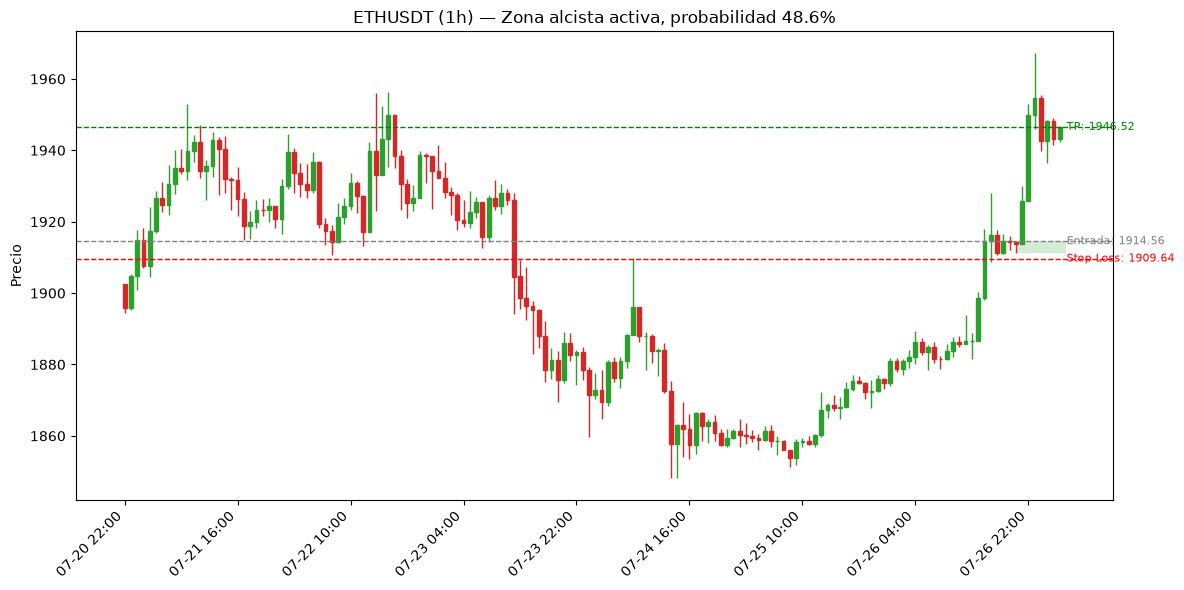

### 15m (zona Order Block y niveles propios)

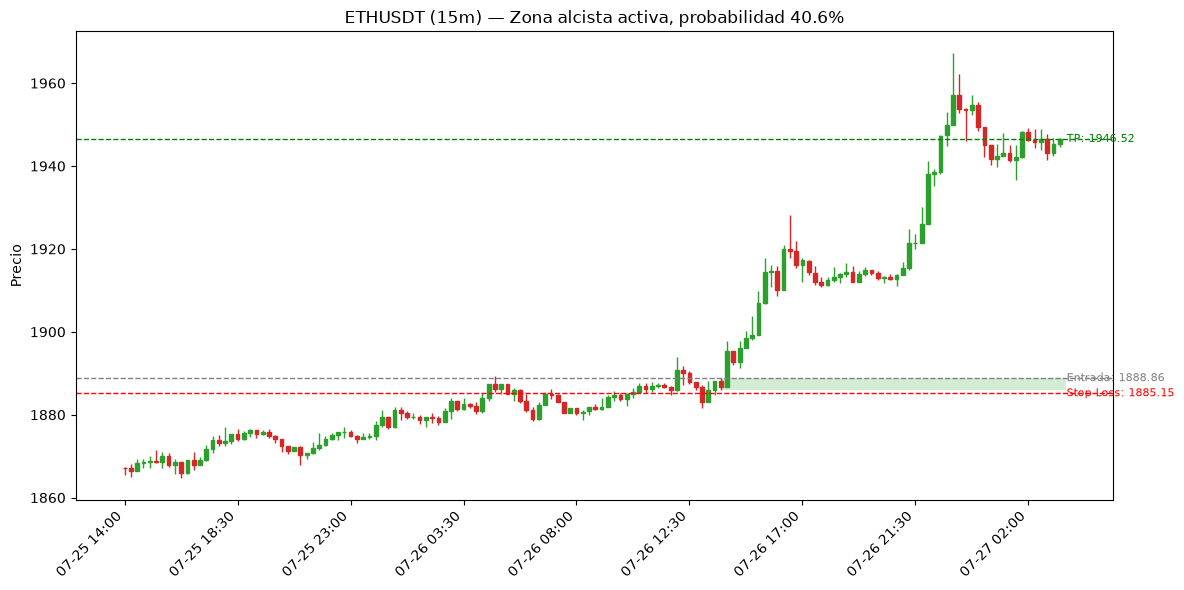

### 5m (zona Order Block y niveles propios)

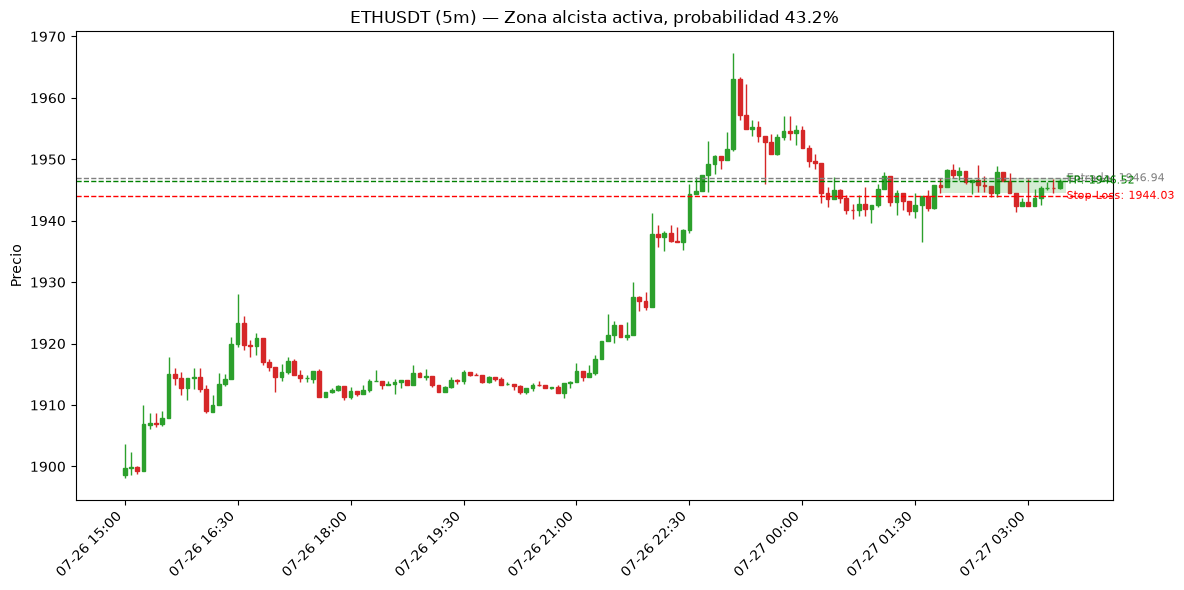

In [19]:
def graficar_velas(ax, df, ancho=0.6, color_alcista="tab:green", color_bajista="tab:red"):
    x = np.arange(len(df))
    colores = np.where(df["close"].values >= df["open"].values, color_alcista, color_bajista)
    ax.vlines(x, df["low"].values, df["high"].values, color=colores, linewidth=1)
    cuerpo_bajo = np.minimum(df["open"].values, df["close"].values)
    cuerpo_alto = np.maximum(df["open"].values, df["close"].values) - cuerpo_bajo
    ax.bar(x, cuerpo_alto, bottom=cuerpo_bajo, width=ancho, color=colores, edgecolor=colores)
    return x


def formatear_eje_x(ax, indice_tiempo, n_ticks=8):
    n = len(indice_tiempo)
    paso = max(1, n // n_ticks)
    posiciones = list(range(0, n, paso))
    etiquetas = [indice_tiempo[i].strftime("%m-%d %H:%M") for i in posiciones]
    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas, rotation=45, ha="right")


def graficar_zona_operativa(df, resultado, n_velas=150):
    df_plot = df.tail(n_velas)
    fig, ax = plt.subplots(figsize=(12, 6))
    x = graficar_velas(ax, df_plot)

    zona_actual = resultado["zona_actual"]
    pos_zona = df_plot.index.get_indexer([zona_actual["tiempo_ob"]])[0]
    if pos_zona == -1:
        pos_zona = 0  # la zona es más antigua que la ventana graficada
    color_zona = "tab:green" if resultado["tipo_zona"] == "alcista" else "tab:red"
    ax.add_patch(Rectangle((pos_zona, zona_actual["zona_low"]), len(df_plot) - pos_zona,
                            zona_actual["zona_high"] - zona_actual["zona_low"],
                            facecolor=color_zona, alpha=0.2, edgecolor="none"))

    for nivel, nombre, color in [(resultado["entrada"], "Entrada", "gray"),
                                  (resultado["stop_loss"], "Stop Loss", "red")]:
        ax.axhline(nivel, color=color, linestyle="--", linewidth=1)
        ax.annotate(f"{nombre}: {nivel:.2f}", xy=(x[-1], nivel), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8, color=color)
    if resultado["take_profit"] is not None:
        ax.axhline(resultado["take_profit"], color="green", linestyle="--", linewidth=1)
        ax.annotate(f"TP: {resultado['take_profit']:.2f}", xy=(x[-1], resultado["take_profit"]), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8, color="green")

    ax.set_title(f"{SYMBOL_BINANCE} ({resultado['etiqueta_tf']}) — Zona {resultado['tipo_zona']} activa, "
                 f"probabilidad {resultado['probabilidad']}%")
    ax.set_ylabel("Precio")
    formatear_eje_x(ax, df_plot.index)
    fig.tight_layout()
    plt.show()


display(Markdown(f"### {TF_MACRO_BINANCE} (zona Order Block y niveles propios)"))
graficar_zona_operativa(df_macro, resultado_1h)

display(Markdown(f"### {TF_DIRECCION_BINANCE} (zona Order Block y niveles propios)"))
graficar_zona_operativa(df_htf, resultado_15m)

display(Markdown(f"### {TF_ENTRADA_BINANCE} (zona Order Block y niveles propios)"))
graficar_zona_operativa(df_ltf, resultado_5m)

## 10. Historial de zonas recientes (1h, 15m y 5m)

In [20]:
def tabla_historial(obs_resultado, n=25):
    columnas = ["tiempo_break", "tipo", "zona_low", "zona_high", "nivel_roto", "resultado"]
    tabla = obs_resultado.tail(n)[columnas].rename(columns={"tiempo_break": "tiempo_quiebre"})
    return tabla.sort_values("tiempo_quiebre", ascending=False).reset_index(drop=True)


display(Markdown(f"### Historial — {TF_MACRO_BINANCE}"))
display(tabla_historial(obs_resultado_macro))

display(Markdown(f"### Historial — {TF_DIRECCION_BINANCE}"))
display(tabla_historial(obs_resultado_htf))

display(Markdown(f"### Historial — {TF_ENTRADA_BINANCE}"))
display(tabla_historial(obs_resultado_ltf))

### Historial — 1h

,tiempo_quiebre,tipo,zona_low,zona_high,nivel_roto,resultado
0,2026-07-26 22:00:00,alcista,1911.14,1914.56,1928.08,sin_toque
1,2026-07-26 00:00:00,alcista,1873.20,1876.20,1877.07,sin_toque
2,2026-07-25 17:00:00,alcista,1867.03,1871.43,1872.35,continuo
3,2026-07-24 13:00:00,bajista,1876.71,1884.71,1859.67,fallo
4,2026-07-23 12:00:00,bajista,1922.13,1930.43,1912.60,fallo
5,2026-07-21 03:00:00,alcista,1907.00,1918.18,1918.16,continuo
6,2026-07-18 17:00:00,alcista,1842.12,1846.35,1850.64,continuo
7,2026-07-17 01:00:00,bajista,1848.32,1866.71,1862.57,continuo
8,2026-07-15 12:00:00,alcista,1874.98,1886.55,1891.89,fallo
9,2026-07-13 12:00:00,bajista,1779.43,1784.98,1773.99,continuo


### Historial — 15m

,tiempo_quiebre,tipo,zona_low,zona_high,nivel_roto,resultado
0,2026-07-26 14:00:00,alcista,1886.00,1888.86,1893.89,sin_toque
1,2026-07-26 10:30:00,alcista,1883.39,1885.35,1886.29,continuo
2,2026-07-26 04:15:00,alcista,1880.26,1883.16,1883.98,fallo
3,2026-07-26 00:00:00,alcista,1873.20,1875.22,1876.92,sin_toque
4,2026-07-25 17:15:00,alcista,1866.62,1870.91,1871.43,continuo
5,2026-07-25 12:45:00,alcista,1856.96,1858.91,1860.09,sin_toque
6,2026-07-25 08:00:00,bajista,1854.61,1858.69,1854.61,fallo
7,2026-07-25 06:30:00,bajista,1857.91,1859.50,1855.93,continuo
8,2026-07-25 00:00:00,alcista,1859.32,1860.95,1861.91,fallo
9,2026-07-24 21:45:00,bajista,1858.63,1861.00,1858.42,fallo


### Historial — 5m

,tiempo_quiebre,tipo,zona_low,zona_high,nivel_roto,resultado
0,2026-07-27 01:55:00,alcista,1944.46,1946.94,1948.00,fallo
1,2026-07-27 00:15:00,bajista,1952.35,1955.54,1945.99,sin_toque
2,2026-07-26 22:30:00,alcista,1936.60,1939.05,1941.31,continuo
3,2026-07-26 21:45:00,alcista,1920.99,1923.05,1924.83,sin_toque
4,2026-07-26 16:25:00,alcista,1908.75,1913.25,1916.01,continuo
5,2026-07-26 14:55:00,alcista,1893.20,1895.00,1897.77,sin_toque
6,2026-07-26 12:45:00,bajista,1889.09,1889.95,1887.17,fallo
7,2026-07-26 12:00:00,alcista,1884.78,1885.97,1887.73,fallo
8,2026-07-26 10:20:00,alcista,1884.11,1885.08,1885.76,continuo
9,2026-07-26 08:00:00,bajista,1880.96,1881.64,1880.51,fallo
